In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## 40. Regresión Simple: Bailabilidad → Reproducciones


In [ ]:
# Cargar los datos
canciones = pd.read_csv('tb_canciones_estadisticas.csv', sep=";")


In [10]:
canciones.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,...,seguidores,total_reproducciones,reproducciones_completadas,ratio_completadas,puntuacion_media,num_valoraciones,en_chart,mejor_posicion_chart,semanas_en_chart,num_playlists
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021,339,electronica,trance,0.86,0.63,...,2272315,35,29.0,0.8286,4.00,6,1,43,1,2
1,2,Tema 2,169,Francisco Stone - Evolución,2022,134,latin,salsa,0.64,0.87,...,134889,24,18.0,0.7500,3.17,6,1,13,4,8
2,3,Tema 3,80,Francisco Stone - Nuevo,2022,123,pop,pop-urbano,0.66,0.58,...,379450,26,19.0,0.7308,3.40,10,1,4,3,6
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021,135,latin,cumbia,0.83,0.91,...,1142190,33,22.0,0.6667,4.08,12,1,26,3,7
4,5,Tema 5,108,Gabriel García - Vueltas,2022,200,pop,pop-latino,0.51,0.59,...,4236247,22,20.0,0.9091,2.71,7,1,12,1,4


In [11]:
X = canciones[['bailabilidad']]
y = canciones['total_reproducciones']

In [13]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
# Entrenamiento
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [15]:
# Prediccion
y_pred = modelo.predict(X_test)

In [16]:
# Evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}')
print(f'R²: {r2}')

MSE: 24.636568174355734
R²: -0.004483628972451692


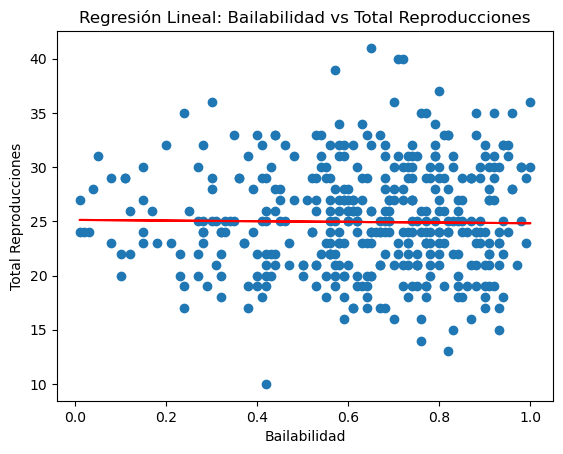

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel('Bailabilidad')
plt.ylabel('Total Reproducciones')
plt.title('Regresión Lineal: Bailabilidad vs Total Reproducciones')
plt.show()

# R2 es bajo porque solo estamos usando una variable (bailabilidad) para predecir el total de reproducciones.

## 41. Regresión Múltiple: Varias Features



In [19]:
features = ['energia', 'bailabilidad', 'valencia', 'acusticidad', 'tempo', 'volumen_db', 'seguidores']

# Escalado de features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(canciones[features]), columns=features)

In [20]:
# Entrenamiento con múltiples features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [21]:
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred_multiple = modelo_multiple.predict(X_test)

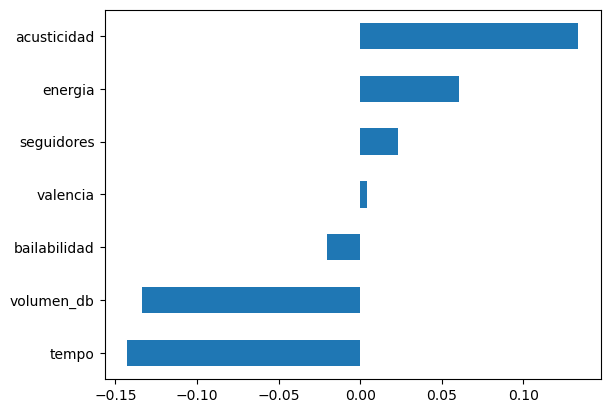

In [23]:
# Barchart de coeficientes
coeficientes = pd.Series(modelo_multiple.coef_, index=features).sort_values().plot(kind='barh')

In [27]:
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f'MSE: {mse_multiple}')
print(f'R²: {r2_multiple}')

MSE: 24.419868766109868
R²: 0.004351652242468695


In [25]:
print(f"Simple: {r2:.4f}, Múltiple: {r2_multiple:.4f}")

Simple: -0.0045, Múltiple: 0.0044
